Análise de Regressão --- Atividade 1 

Enunciado:
Um pesquisador deseja estudar a relação entre o Consumo (km/l) de um automóvel e a sua
Velocidade Média em um percurso fixo.
1. Gere um conjunto de dados coerente com este problema e apresente o código
utilizado.
2. Ajuste a reta de regressão linear.
3. Apresente os resultados e compare-os com o processo de geração dos dados.
4. Discuta os resultados obtidos.

### 1. Gere um conjunto de dados coerente com este problema e apresente o código utilizado.

Observação: 
Se a gente analisar de forma literal, a unidade km/l se refere à eficiência do automóvel, e a unidade correta para medir o consumo de combustível seria litro por quilômetro (L/km) ou litro por 100 quilômetro (L/100km). 

Eu escolho usar L/100km para a variável Consumo nessa atividade.

um link externo para um url que justifica minha escolha: https://www.terra.com.br/mobilidade/carros/brasileiro-nao-sabe-medir-consumo-do-carro-entenda-o-porque,c114a004c29459e53be9499b53fad9d543q2tx2w.html

O código em R abaixo é usado para gerar os dados

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd
random.seed(20260317)

n = 500 # número de observações / tamanho da amostra
beta_0 = 5    # os parâmetros
beta_1 = 0.015

X = np.random.uniform(low = 20, high = 150, size = n)
Erros = np.random.normal(loc = 0, scale = 0.5, size = n)

Y = beta_0 + beta_1 * X + Erros # "Calcular" Y

### 2. Ajuste a reta de regressão linear.


Text(0, 0.5, 'Consumo')

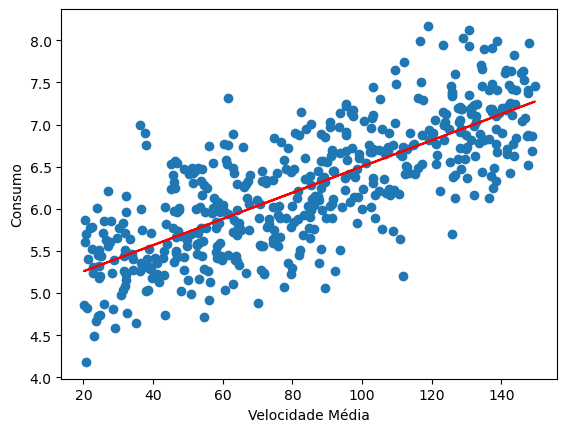

In [6]:
plt.scatter(X, Y)
beta_1_chapeu, beta_0_chapeu  = np.polyfit(X, Y, 1)
plt.plot(X, beta_0_chapeu + beta_1_chapeu*X, color='red', label=f' Reta de regressão linear simples: Y = {beta_0_chapeu:.2f} + {beta_1_chapeu:.2f}X')
plt.xlabel('Velocidade Média')
plt.ylabel('Consumo')

Comentários sobre o gráfico: Os dados mostram uma tendência positiva, e a nuvem de dados apresenta uma dispersão uniforme, o que é esperado já que os erros gerados são homocedásticos. Além disso note que a reta de regressão linear e a reta teórica são proxímas, e elas possuem uma diferença pequena devido ao erro aleatório gerado acima no código.

### 3. Apresente os resultados e compare-os com o processo de geração dos dados.


In [8]:
correlacao = np.corrcoef(X, Y)[0,1]

print(f"Coeficiente de Correlação (X,Y):{correlacao:.4f}")

comparacao = pd.DataFrame({
    "Parametro": ["Intercepto", "Inclinação"],
    "Verdadeiros":[beta_0, beta_1],
    "Estimados":[beta_0_chapeu,beta_1_chapeu],
    "Erro Absoluto":[
        abs(beta_0_chapeu-beta_0),
        abs(beta_1_chapeu - beta_1)
    ],
    "Erro relativo":[
        abs(beta_0_chapeu-beta_0)/beta_0,
        abs(beta_1_chapeu - beta_1)/beta_1                  
    ]
})
print(comparacao)

Coeficiente de Correlação (X,Y):0.7600
    Parametro  Verdadeiros  Estimados  Erro Absoluto  Erro relativo
0  Intercepto        5.000   4.946700       0.053300        0.01066
1  Inclinação        0.015   0.015556       0.000556        0.03707


Foi calculado o coeficiente de correlação entre as variáveis X e Y, o qual apresentou valor positivo (0.7600). Além disso, com os erros relativos são calculados acima, os coeficientes estimados pelo modelo de regressão linear simples são próximos dos valores utilizados no processo de geração dos dados. Existe uma pequena diferença entre os valores estimados e valores verdadeiros, e isso é esperado para acontecer já que houve uma presença de um erro aleatório.

### 4. Discuta os resultados obtidos.


Pode-se observar que os dados apresentam uma tendência linear crescente, ou seja quando a velocidade média do automóvel aumenta, o seu consumo de combustível tende a aumentar. 

O modelo de regressão linear usado para gerar dados assume que a relação entre as variáveis é (aproximadamente) linear, os erros aleatórios são homocedásticos,

Talvez o modelo não seja o ideal nas situações reais, já que as pessoas pensariam em usar um modelo diferente (por exemplo um modelo parabólico da forma Y = a + bX + cX^2 + erro). Mas, no contexto dessa atividade, acredito o objetivo seja ilustrar o ajuste de um modelo regressão linear simples, o que justificaria a minha escolha.